In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('data/loan_approval_dataset.csv')

# Clean leading/trailing spaces from column headers
df.columns = df.columns.str.strip()

# Clean leading/trailing spaces from string text values inside the columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

print("Dataset Ingested & Whitespaces Cleaned Successfully!")
print(f"Dataset Shape: {df.shape} (Rows, Columns)")
print("\nFirst 5 Records:")
print(df.head())


Matplotlib is building the font cache; this may take a moment.


Dataset Ingested & Whitespaces Cleaned Successfully!
Dataset Shape: (4269, 13) (Rows, Columns)

First 5 Records:
   loan_id  no_of_dependents     education self_employed  income_annum  \
0        1                 2      Graduate            No       9600000   
1        2                 0  Not Graduate           Yes       4100000   
2        3                 3      Graduate            No       9100000   
3        4                 3      Graduate            No       8200000   
4        5                 5  Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxur

In [2]:
print("Data Summary Statistics:")
print(df.describe())

print("\nMissing Values per Feature:")
print(df.isnull().sum())

print("\nTarget Class Distribution:")
print(df['loan_status'].value_counts(normalize=True) * 100)



Data Summary Statistics:
           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    20.000000   

       cibil_score  residential_assets_value  commercial_assets_value  \
count  4269.000000              4.269000e+03             4.269000e+03   
mean    599.936051              7.472617e+06             4.973155e+06   
std     172.430401        

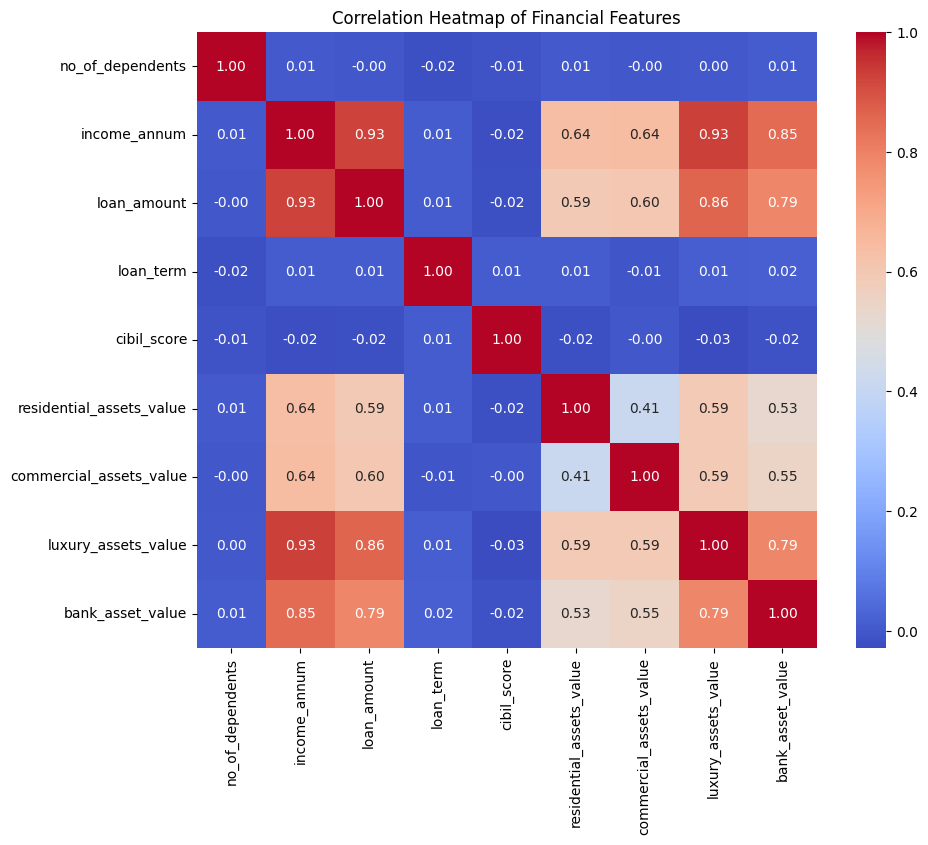

In [3]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['loan_id'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Financial Features')
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Drop redundant identifiers
X = df.drop(columns=['loan_id', 'loan_status'])
y = df['loan_status']

# Label encode categorical text columns
le = LabelEncoder()
cat_cols = ['education', 'self_employed']
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Encode target values ('Approved' -> 0, 'Rejected' -> 1)
y = y.map({'Approved': 0, 'Rejected': 1})

# Train-Test Split (80% training, 20% validation testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and apply StandardScaler to normalize continuous ranges
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a baseline Random Forest Classifier
clf = RandomForestClassifier(random_state=42, n_estimators=100)
clf.fit(X_train_scaled, y_train)

# Evaluate
y_pred = clf.predict(X_test_scaled)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Baseline Accuracy: 98.13%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.96      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

